# Lab Assignment Seven: Sequential Network Architectures

**Team Members:** Emilio Munoz, Andy Su, Jadon Swearingen  
**Date:** 05/14/26  
**Dataset:** IMDB Movie Reviews (50K, binary sentiment)

## Part 0: Imports and Setup

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')
print(f'Using device: {device}')

Using device: mps


---
## Part 1: Preparation

### 1.1 Dataset Loading and Description

**Dataset:** IMDB Movie Reviews (Kaggle)

- **Source:** [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews), collected from the Internet Movie Database
- **Number of samples:** 50,000
- **Number of classes:** 2, positive and negative sentiment
- **Class distribution:** Balanced, 25,000 positive and 25,000 negative
- **Task:** Many to one sequence classification. Given a full review, predict a single sentiment label

In [23]:
df = pd.read_csv('IMDB Dataset.csv')
texts = df['review'].tolist()
labels = (df['sentiment'] == 'positive').astype(int).tolist()  # 1=positive, 0=negative

print(f'Total samples: {len(texts)}')
print(f'Class distribution: {Counter(labels)}')
print(f'\nSample text:\n{texts[0][:300]}')

Total samples: 50000
Class distribution: Counter({1: 25000, 0: 25000})

Sample text:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru


### 1.2 Preprocessing and Tokenization

We went with word-level tokenization. The main reason is that we're using GloVe embeddings which are word-level, so something like BPE would've meant throwing out the pretrained weights entirely and learning from scratch. That's a bad trade when we only have 50K reviews. Word-level is also just easier to debug.

The downside is out-of-vocabulary words. Anything unusual or misspelled just gets mapped to UNK. For IMDB that's mostly fine since the reviews are standard English and a 20,000-word vocab covers the vast majority of what comes up.

For sequence length, IMDB reviews vary a lot. We looked at the distribution and the 95th percentile is around 400 words, so that's what we set MAX_LEN to. Less than 5% of reviews get cut at all, and even those only lose the tail end which usually doesn't change the overall sentiment anyway. Shorter reviews get padded on the right.

**What we cleaned:**
- Stripped HTML tags. The raw data has a lot of br tags from the original IMDB formatting
- Lowercased everything since GloVe is also lowercase
- Removed punctuation since GloVe doesn't have embeddings for things like exclamation marks anyway
- Collapsed leftover whitespace

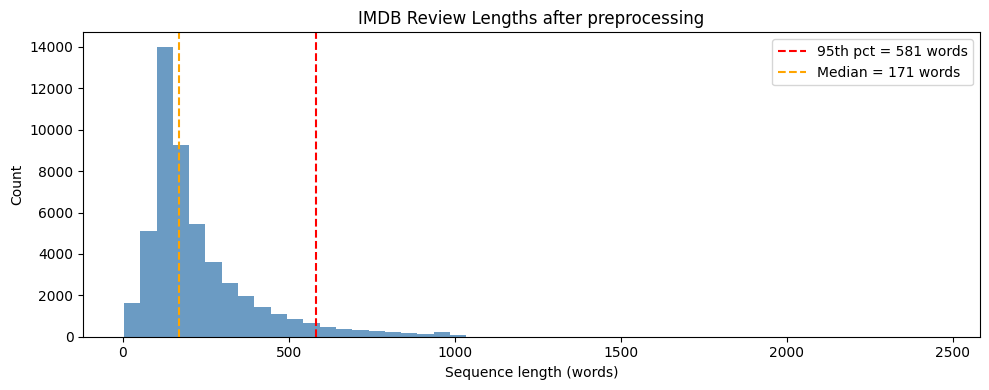

Mean: 227.9
Median: 171.0
95th percentile: 581.0
Max: 2459


In [24]:
def preprocess_text(text):
    text = re.sub(r'<[^>]+>', ' ', text)  # strip html
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_texts = [preprocess_text(t) for t in texts]

lengths = [len(t.split()) for t in cleaned_texts]
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', alpha=0.8)
plt.axvline(np.percentile(lengths, 95), color='red', linestyle='--',
            label=f'95th pct = {np.percentile(lengths, 95):.0f} words')
plt.axvline(np.median(lengths), color='orange', linestyle='--',
            label=f'Median = {np.median(lengths):.0f} words')
plt.xlabel('Sequence length (words)')
plt.ylabel('Count')
plt.title('IMDB Review Lengths after preprocessing')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mean: {np.mean(lengths):.1f}')
print(f'Median: {np.median(lengths):.1f}')
print(f'95th percentile: {np.percentile(lengths, 95):.1f}')
print(f'Max: {np.max(lengths)}')

In [25]:
MAX_LEN = 400
VOCAB_SIZE = 20000
EMBED_DIM = 100  # using glove 100d

all_words = [word for text in cleaned_texts for word in text.split()]
word_counts = Counter(all_words)
vocab = ['<PAD>', '<UNK>'] + [w for w, _ in word_counts.most_common(VOCAB_SIZE - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

def tokenize_and_pad(text, max_len=MAX_LEN):
    tokens = [word2idx.get(w, 1) for w in text.split()]
    tokens = tokens[:max_len]
    tokens += [0] * (max_len - len(tokens))
    return tokens

X = np.array([tokenize_and_pad(t) for t in cleaned_texts])
y = np.array(labels)

print(f'X shape: {X.shape}')
print(f'Vocab size: {len(vocab)}')

X shape: (50000, 400)
Vocab size: 20000


### 1.3 Evaluation Metric

We're using macro F1 as the main metric, with accuracy reported alongside it.

The dataset is balanced so accuracy would technically be fine here, but we think F1 is still the better choice. If the model mislabels a negative review as positive it ends up promoting a bad movie to users. If it buries a positive review that's also a problem for the platform. These are two different kinds of errors and F1 accounts for both, while accuracy just counts what's correct overall.

There's also the deployment side of things. The training data is 50/50 but that won't hold once the model is actually running. A film that flops might have 90% negative reviews. F1 would catch if the model starts leaning toward one class in those situations, whereas accuracy might not.

In practice on a balanced dataset like this the two metrics will stay close, so we're reporting both. If they ever diverge noticeably that's a sign something's off.

In [26]:
from sklearn.metrics import accuracy_score

def evaluate(y_true, y_pred):
    
    return {

        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'accuracy': accuracy_score(y_true, y_pred),
        
    }

### 1.4 Train/Test Split

We're using stratified 5-fold cross-validation instead of the fixed train/test split that comes with the IMDB dataset.

The issue with a single split is you get one number and there's no way to know if it's representative. Since we're comparing multiple models in Part 8, we need more than one data point per model to actually run a statistical test. With 5-fold CV each model gets five F1 scores and every review gets used for validation at some point.

We kept the folds stratified even though the dataset is already balanced. It's a small thing but it guarantees the class ratio stays consistent across folds rather than drifting slightly.

We went with k=5 over k=10 mainly because of compute. Ten folds would roughly double training time and for a 50K dataset the accuracy gain isn't really worth it.

In [27]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(X, y))

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f'Fold {fold_idx+1}: train={len(train_idx)}, val={len(val_idx)}')

print('\nClass distribution preserved across folds (stratified).')

Fold 1: train=40000, val=10000
Fold 2: train=40000, val=10000
Fold 3: train=40000, val=10000
Fold 4: train=40000, val=10000
Fold 5: train=40000, val=10000

Class distribution preserved across folds (stratified).


---
## Part 2: Pre-trained Embeddings

We're using GloVe 6B 100d embeddings rather than starting from random weights. GloVe was trained on 6 billion tokens from Wikipedia and Gigaword, so the model already has a decent sense of word similarity before it ever sees an IMDB review. Words like "excellent" and "great" already cluster together, same with "terrible" and "awful". That's a useful head start for sentiment.

We went with 100 dimensions instead of 200d or 300d mostly for speed. The embedding size carries through the whole model so going bigger means slower training across the board. For a binary sentiment task on clean English text 100d is enough.

Any word that's not in GloVe just gets a small random initialization and gets updated during training. The PAD token stays zeroed out. GloVe coverage on IMDB is usually above 90% so this doesn't come up that often.

Make sure glove.6B.100d.txt is in the same folder as this notebook before running.

In [28]:
GLOVE_PATH = 'glove.6B.100d.txt'

def load_glove(path, word2idx, embed_dim):

    embedding_matrix = np.random.uniform(-0.1, 0.1, (len(word2idx), embed_dim))
    embedding_matrix[0] = 0  # <PAD> = zero vector
    found = 0
    
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word = parts[0]
            if word in word2idx:
                embedding_matrix[word2idx[word]] = np.array(parts[1:], dtype=np.float32)
                found += 1
    print(f'GloVe coverage: {found}/{len(word2idx)} words ({100*found/len(word2idx):.1f}%)')
    return torch.FloatTensor(embedding_matrix)

glove_weights = load_glove(GLOVE_PATH, word2idx, EMBED_DIM)

GloVe coverage: 19463/20000 words (97.3%)


---
## Part 3: Dataset and DataLoader

In [29]:
class TextDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


BATCH_SIZE = 64
NUM_CLASSES = len(set(labels))
print(f'Number of classes: {NUM_CLASSES}')

Number of classes: 2


In [30]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters=128, kernel_sizes=(3, 4, 5),
                 dropout=0.5, pretrained_embeddings=None, freeze_embed=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = not freeze_embed

        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)  # (B, embed_dim, L)
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        x = torch.cat(pooled, dim=1)
        x = self.dropout(x)
        return self.fc(x)

### 4.2 Architecture 2 — Transformer

In [38]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-np.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_heads=4, ff_dim=256, dropout=0.1,
                 pretrained_embeddings=None, freeze_embed=False,
                 num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = not freeze_embed

        self.pos_enc = PositionalEncoding(embed_dim, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout, batch_first=True
        )
        # enable_nested_tensor=False: the nested-tensor fast path uses an op
        # that isn't implemented on MPS; disabling it keeps the model portable
        # across CPU/MPS/CUDA at a negligible speed cost on this size.
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers, enable_nested_tensor=False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        pad_mask = (x == 0)
        x = self.embedding(x)
        x = self.pos_enc(x)
        x = self.transformer(x, src_key_padding_mask=pad_mask)
        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.fc(x)

---
## Part 5: Training Loop

In [32]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_batch)
        history['train_loss'].append(total_loss / len(train_loader.dataset))

        model.eval()
        val_loss, all_preds, all_true = 0, [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                val_loss += criterion(logits, y_batch).item() * len(y_batch)
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_true.extend(y_batch.cpu().numpy())
        history['val_loss'].append(val_loss / len(val_loader.dataset))
        history['val_f1'].append(f1_score(all_true, all_preds, average='macro'))

        print(f'  Epoch {epoch+1}/{epochs} | '
              f'train_loss={history["train_loss"][-1]:.4f} | '
              f'val_loss={history["val_loss"][-1]:.4f} | '
              f'val_f1={history["val_f1"][-1]:.4f}')

    return history


def plot_history(history, title='Model'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss'); ax1.legend()

    ax2.plot(epochs, history['val_f1'], label='Val Macro F1', color='green')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
    ax2.set_title(f'{title} — Validation F1'); ax2.legend()

    plt.tight_layout()
    plt.show()

---
## Part 6: Two Architectures + Hyperparameter Tuning

Train at least 4 models total (2 CNN variants + 2 Transformer variants). For each architecture, adjust **one** hyperparameter to try to improve generalization. Visualize training/validation loss and F1 for each model to show convergence.

**CNN hyperparameter to tune:** `num_filters` (try 128 vs. 256) — or justify a different choice.  
**Transformer hyperparameter to tune:** `ff_dim` (try 256 vs. 512) — or justify a different choice.

In [33]:
EPOCHS = 15  # TODO: increase if models have not converged
LR = 1e-3

# Use fold 0 for architecture comparison
train_idx, val_idx = folds[0]
train_ds = TextDataset(X[train_idx], y[train_idx])
val_ds   = TextDataset(X[val_idx],   y[val_idx])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

=== Model 1: CNN Baseline (num_filters=128) ===
  Epoch 1/15 | train_loss=0.4056 | val_loss=0.2840 | val_f1=0.8784
  Epoch 2/15 | train_loss=0.2470 | val_loss=0.2438 | val_f1=0.8988
  Epoch 3/15 | train_loss=0.1748 | val_loss=0.2544 | val_f1=0.8942
  Epoch 4/15 | train_loss=0.1221 | val_loss=0.2744 | val_f1=0.8970
  Epoch 5/15 | train_loss=0.0808 | val_loss=0.3093 | val_f1=0.8968
  Epoch 6/15 | train_loss=0.0543 | val_loss=0.3696 | val_f1=0.8925
  Epoch 7/15 | train_loss=0.0419 | val_loss=0.4442 | val_f1=0.8881
  Epoch 8/15 | train_loss=0.0329 | val_loss=0.4771 | val_f1=0.8908
  Epoch 9/15 | train_loss=0.0282 | val_loss=0.5152 | val_f1=0.8903
  Epoch 10/15 | train_loss=0.0245 | val_loss=0.5931 | val_f1=0.8899
  Epoch 11/15 | train_loss=0.0236 | val_loss=0.5978 | val_f1=0.8928
  Epoch 12/15 | train_loss=0.0206 | val_loss=0.6671 | val_f1=0.8912
  Epoch 13/15 | train_loss=0.0178 | val_loss=0.7049 | val_f1=0.8881
  Epoch 14/15 | train_loss=0.0196 | val_loss=0.7440 | val_f1=0.8875
  Epoch 1

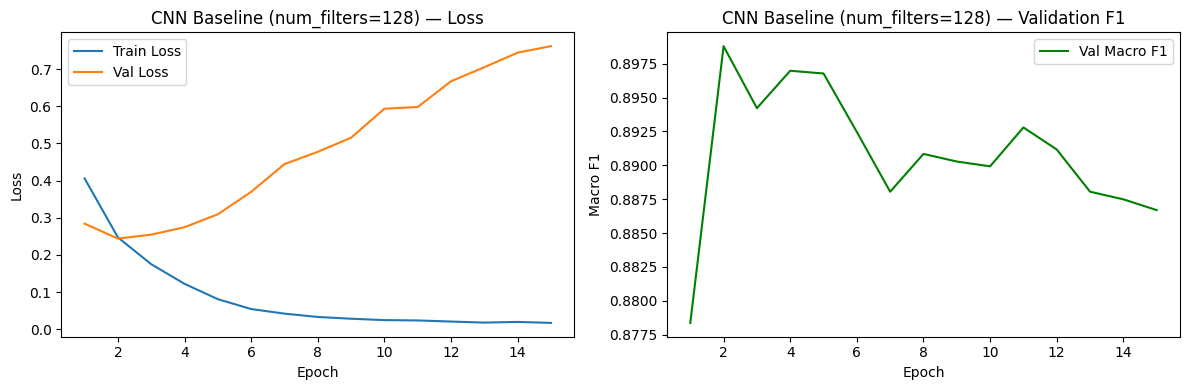

In [34]:
# --- Model 1: CNN Baseline ---
print('=== Model 1: CNN Baseline (num_filters=128) ===')
cnn_baseline = TextCNN(
    vocab_size=len(vocab), embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
    num_filters=128, dropout=0.5, pretrained_embeddings=glove_weights
)
hist_cnn_base = train_model(cnn_baseline, train_loader, val_loader, epochs=EPOCHS, lr=LR)
plot_history(hist_cnn_base, 'CNN Baseline (num_filters=128)')

**Model 2 Hyperparameter Value Justification:**

For Model 2 we increased num_filters from 128 to 256. Each filter in the CNN learns one phrase pattern independently, so num_filters directly controls how many distinct patterns the conv layer can capture in parallel. Doubling it gives the model twice as many of these detectors per kernel size.

We considered adjusting kernel_sizes or dropout instead, but those control what shape of pattern the model looks at and how aggressively it regularizes. It does not look at how many patterns it can learn. num_filters felt like the cleanest hyperparameter for raw capacity.

We decided on 256 because IMDB reviews have a lot of subtle sentiment phrasing, such as sarcasm, double negatives, etc.,  that 128 filters can't fully cover. Going higher (512, 1024) would start risking overfitting on the training set. 



=== Model 2: CNN Tuned (num_filters=256) ===
  Epoch 1/15 | train_loss=0.3965 | val_loss=0.2696 | val_f1=0.8840
  Epoch 2/15 | train_loss=0.2372 | val_loss=0.2459 | val_f1=0.8974
  Epoch 3/15 | train_loss=0.1633 | val_loss=0.2468 | val_f1=0.9040
  Epoch 4/15 | train_loss=0.1062 | val_loss=0.2777 | val_f1=0.8991
  Epoch 5/15 | train_loss=0.0658 | val_loss=0.3356 | val_f1=0.8958
  Epoch 6/15 | train_loss=0.0453 | val_loss=0.4094 | val_f1=0.8945
  Epoch 7/15 | train_loss=0.0309 | val_loss=0.4622 | val_f1=0.8933
  Epoch 8/15 | train_loss=0.0270 | val_loss=0.5722 | val_f1=0.8860
  Epoch 9/15 | train_loss=0.0260 | val_loss=0.5580 | val_f1=0.8916
  Epoch 10/15 | train_loss=0.0231 | val_loss=0.6016 | val_f1=0.8940
  Epoch 11/15 | train_loss=0.0177 | val_loss=0.6885 | val_f1=0.8898
  Epoch 12/15 | train_loss=0.0198 | val_loss=0.7763 | val_f1=0.8855
  Epoch 13/15 | train_loss=0.0189 | val_loss=0.7928 | val_f1=0.8832
  Epoch 14/15 | train_loss=0.0201 | val_loss=0.8517 | val_f1=0.8820
  Epoch 15/1

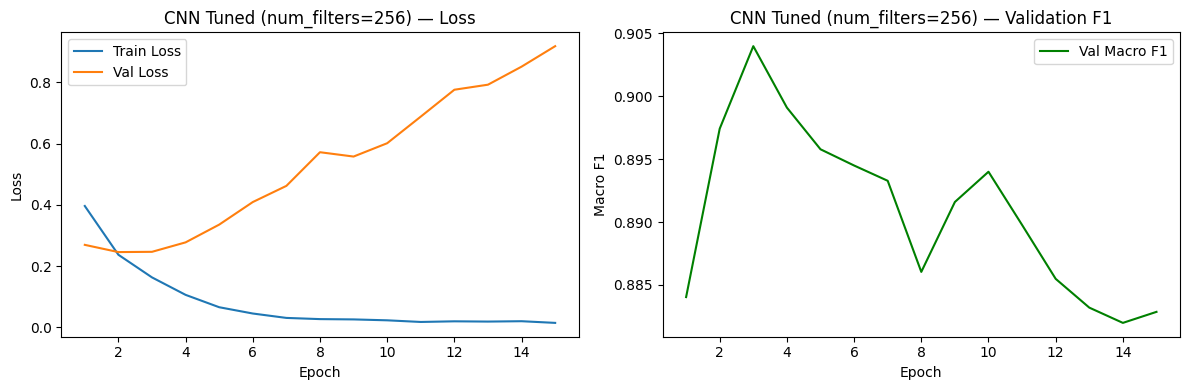

In [36]:
# --- Model 2: CNN Tuned ---
print('=== Model 2: CNN Tuned (num_filters=256) ===')
cnn_tuned = TextCNN(
    vocab_size=len(vocab), embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
    num_filters=256, dropout=0.5, pretrained_embeddings=glove_weights
)
hist_cnn_tuned = train_model(cnn_tuned, train_loader, val_loader, epochs=EPOCHS, lr=LR)
plot_history(hist_cnn_tuned, 'CNN Tuned (num_filters=256)')

=== Model 3: Transformer Baseline (ff_dim=256) ===
  Epoch 1/15 | train_loss=0.3996 | val_loss=0.3051 | val_f1=0.8717
  Epoch 2/15 | train_loss=0.2517 | val_loss=0.2859 | val_f1=0.8796
  Epoch 3/15 | train_loss=0.1949 | val_loss=0.2631 | val_f1=0.8934
  Epoch 4/15 | train_loss=0.1540 | val_loss=0.3082 | val_f1=0.8889
  Epoch 5/15 | train_loss=0.1175 | val_loss=0.3119 | val_f1=0.8876
  Epoch 6/15 | train_loss=0.0954 | val_loss=0.3512 | val_f1=0.8909
  Epoch 7/15 | train_loss=0.0752 | val_loss=0.4586 | val_f1=0.8853
  Epoch 8/15 | train_loss=0.0651 | val_loss=0.4625 | val_f1=0.8764
  Epoch 9/15 | train_loss=0.0515 | val_loss=0.4826 | val_f1=0.8833
  Epoch 10/15 | train_loss=0.0439 | val_loss=0.4889 | val_f1=0.8789
  Epoch 11/15 | train_loss=0.0381 | val_loss=0.5606 | val_f1=0.8789
  Epoch 12/15 | train_loss=0.0315 | val_loss=0.6036 | val_f1=0.8738
  Epoch 13/15 | train_loss=0.0278 | val_loss=0.6614 | val_f1=0.8703
  Epoch 14/15 | train_loss=0.0257 | val_loss=0.6268 | val_f1=0.8771
  Epoc

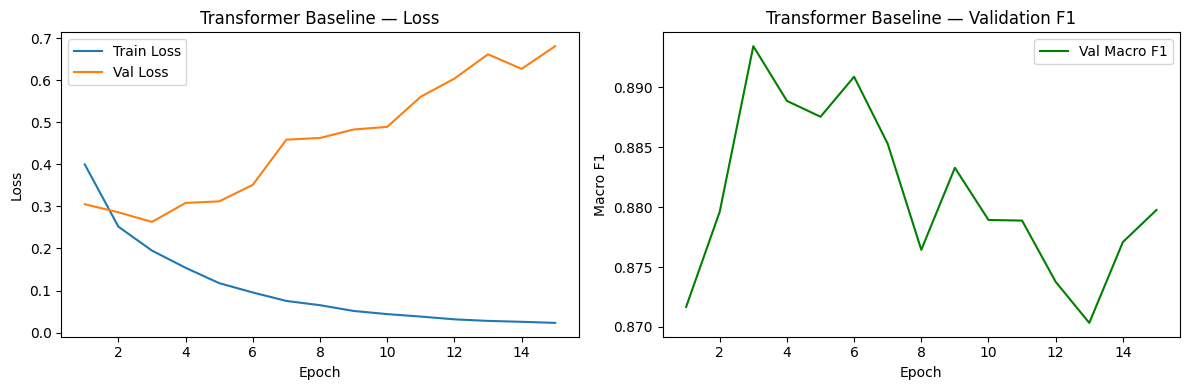

In [39]:
# --- Model 3: Transformer Baseline ---
print('=== Model 3: Transformer Baseline (ff_dim=256) ===')
transformer_baseline = TransformerClassifier(
    vocab_size=len(vocab), embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
    num_heads=4, ff_dim=256, dropout=0.1, pretrained_embeddings=glove_weights
)
hist_trans_base = train_model(transformer_baseline, train_loader, val_loader, epochs=EPOCHS, lr=LR)
plot_history(hist_trans_base, 'Transformer Baseline')

**Model 4 Hyperparameter Value Justification:**

For Model 4 we increased ff_dim from 256 to 512. Inside each Transformer encoder layer, the feedforward network is a 2-layer MLP that takes each token's contextualized representation and applies learned per-token features to it. ff_dim is the hidden width of that MLP, which is basically how many neurons the FFN gets to use when transforming each token. Doubling it gives the model more capacity to express a little more suble per-position features after attention completes its mixing of information. 

We chose 512 because the standard rule of thumb is ff_dim ≈ 4 × embed_dim, which for our 100-dim GloVe vectors would be 400. The baseline value of 256 sits below that ratio and the tuned 512 sits above it (5.12×), so the comparison brackets the conventional value and tests whether more capacity helps or hurts on IMDB. Going higher (e.g. 1024) would risk overfitting on a 40K training set. 

=== Model 4: Transformer Tuned (ff_dim=512) ===
  Epoch 1/15 | train_loss=0.4018 | val_loss=0.3018 | val_f1=0.8692
  Epoch 2/15 | train_loss=0.2526 | val_loss=0.2633 | val_f1=0.8904
  Epoch 3/15 | train_loss=0.1969 | val_loss=0.2924 | val_f1=0.8842
  Epoch 4/15 | train_loss=0.1567 | val_loss=0.2851 | val_f1=0.8965
  Epoch 5/15 | train_loss=0.1199 | val_loss=0.3084 | val_f1=0.8928
  Epoch 6/15 | train_loss=0.0981 | val_loss=0.3082 | val_f1=0.8904
  Epoch 7/15 | train_loss=0.0757 | val_loss=0.3969 | val_f1=0.8851
  Epoch 8/15 | train_loss=0.0627 | val_loss=0.4264 | val_f1=0.8873
  Epoch 9/15 | train_loss=0.0514 | val_loss=0.4430 | val_f1=0.8859
  Epoch 10/15 | train_loss=0.0412 | val_loss=0.5217 | val_f1=0.8803
  Epoch 11/15 | train_loss=0.0354 | val_loss=0.5991 | val_f1=0.8788
  Epoch 12/15 | train_loss=0.0296 | val_loss=0.6586 | val_f1=0.8810
  Epoch 13/15 | train_loss=0.0287 | val_loss=0.7476 | val_f1=0.8742
  Epoch 14/15 | train_loss=0.0240 | val_loss=0.6235 | val_f1=0.8730
  Epoch 1

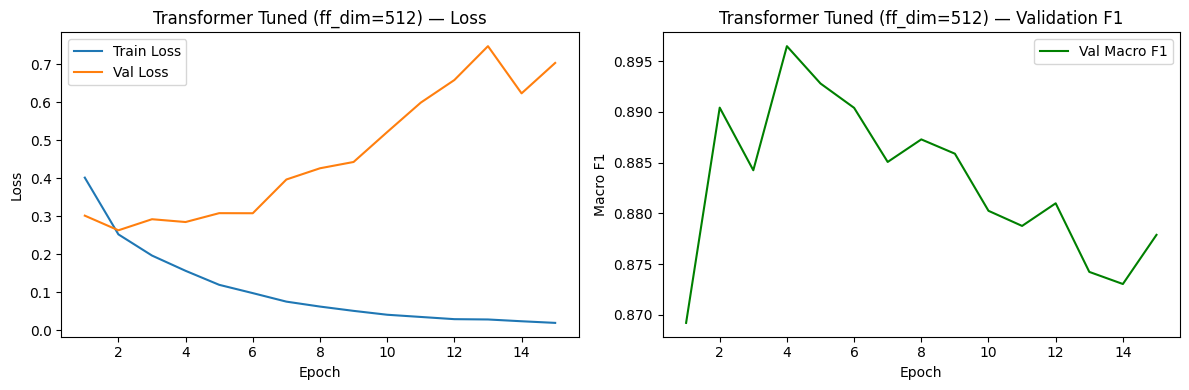

In [41]:
# --- Model 4: Transformer Tuned ---
print('=== Model 4: Transformer Tuned (ff_dim=512) ===')
transformer_tuned = TransformerClassifier(
    vocab_size=len(vocab), embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
    num_heads=4, ff_dim=512, dropout=0.1, pretrained_embeddings=glove_weights
)
hist_trans_tuned = train_model(transformer_tuned, train_loader, val_loader, epochs=EPOCHS, lr=LR)
plot_history(hist_trans_tuned, 'Transformer Tuned (ff_dim=512)')

## Part 7: Second Multi-Headed Attention Layer

Using the best Transformer configuration from Part 6, add a second self-attention layer (`num_layers=2`). The output of the first attention layer feeds directly into the second. Visualize convergence to show the model trained successfully.

**According to the val_f1 values for 3 and 4, Model 4 has a value of 0.8965 at epoch 4, which edges out Model 3's 0.8934 at epoch 3. Thus, the full configs to carry out for part 7 are: num_heads = 4; ff_dim = 512; dropout = 01; embed_dim = 100; and pretrained_embeddings = glove_weights**


=== Model 5: Transformer 2-Layer (num_heads=4, ff_dim=512, num_layers=2) ===
  Epoch 1/15 | train_loss=0.4107 | val_loss=0.2877 | val_f1=0.8792
  Epoch 2/15 | train_loss=0.2529 | val_loss=0.2854 | val_f1=0.8911
  Epoch 3/15 | train_loss=0.1948 | val_loss=0.2621 | val_f1=0.8999
  Epoch 4/15 | train_loss=0.1555 | val_loss=0.2772 | val_f1=0.8968
  Epoch 5/15 | train_loss=0.1232 | val_loss=0.2713 | val_f1=0.8939
  Epoch 6/15 | train_loss=0.1014 | val_loss=0.3049 | val_f1=0.8911
  Epoch 7/15 | train_loss=0.0848 | val_loss=0.4136 | val_f1=0.8853
  Epoch 8/15 | train_loss=0.0685 | val_loss=0.4592 | val_f1=0.8797
  Epoch 9/15 | train_loss=0.0594 | val_loss=0.4811 | val_f1=0.8830
  Epoch 10/15 | train_loss=0.0496 | val_loss=0.4580 | val_f1=0.8812
  Epoch 11/15 | train_loss=0.0444 | val_loss=0.4548 | val_f1=0.8873
  Epoch 12/15 | train_loss=0.0379 | val_loss=0.4911 | val_f1=0.8827
  Epoch 13/15 | train_loss=0.0371 | val_loss=0.5687 | val_f1=0.8817
  Epoch 14/15 | train_loss=0.0301 | val_loss=0.5

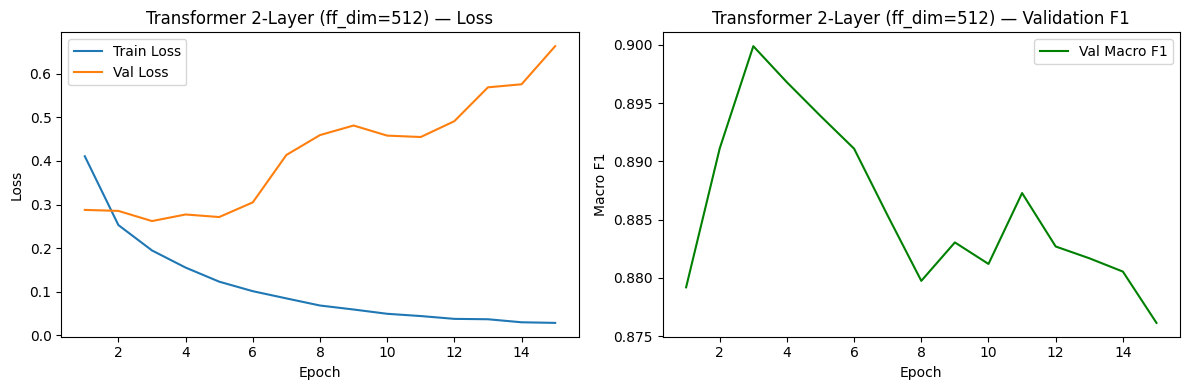

In [43]:
#Model 5: Transformer 2-Layer
print('=== Model 5: Transformer 2-Layer (num_heads=4, ff_dim=512, num_layers=2) ===')
transformer_2layer = TransformerClassifier(
    vocab_size=len(vocab), embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
    num_heads=4, ff_dim=512, dropout=0.1, num_layers=2,
    pretrained_embeddings=glove_weights
)
hist_trans_2layer = train_model(transformer_2layer, train_loader, val_loader, epochs=EPOCHS, lr=LR)
plot_history(hist_trans_2layer, 'Transformer 2-Layer (ff_dim=512)')

---
## Part 8: Full Cross-Validation + Visualize and Compare All Models

Run 5-fold CV for all 5 model configurations. Report mean ± std Macro F1. Visualize results and apply a statistical test to determine which model(s) are significantly better.

In [44]:
def run_cross_validation(model_fn, folds, X, y, epochs=EPOCHS, lr=LR):
    fold_f1s = []
    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f'  Fold {fold_idx+1}/{len(folds)}...')
        train_ds = TextDataset(X[train_idx], y[train_idx])
        val_ds   = TextDataset(X[val_idx],   y[val_idx])
        tl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        vl = DataLoader(val_ds,   batch_size=BATCH_SIZE)
        history = train_model(model_fn(), tl, vl, epochs=epochs, lr=lr)
        fold_f1s.append(max(history['val_f1']))
    print(f'  CV Macro F1: {np.mean(fold_f1s):.4f} +/- {np.std(fold_f1s):.4f}')
    return fold_f1s

In [ ]:
print('=== CNN Baseline CV ===')
cv_cnn_base = run_cross_validation(
    lambda: TextCNN(len(vocab), EMBED_DIM, NUM_CLASSES, num_filters=128,
                    pretrained_embeddings=glove_weights), folds, X, y)

print('\n=== CNN Tuned CV ===')
cv_cnn_tuned = run_cross_validation(
    lambda: TextCNN(len(vocab), EMBED_DIM, NUM_CLASSES, num_filters=256,
                    pretrained_embeddings=glove_weights), folds, X, y)

print('\n=== Transformer Baseline CV ===')
cv_trans_base = run_cross_validation(
    lambda: TransformerClassifier(len(vocab), EMBED_DIM, NUM_CLASSES,
                                  num_heads=4, ff_dim=256,
                                  pretrained_embeddings=glove_weights), folds, X, y)

print('\n=== Transformer Tuned CV ===')
cv_trans_tuned = run_cross_validation(
    lambda: TransformerClassifier(len(vocab), EMBED_DIM, NUM_CLASSES,
                                  num_heads=4, ff_dim=512,
                                  pretrained_embeddings=glove_weights), folds, X, y)

print('\n=== Transformer 2-Layer CV ===')
cv_trans_2layer = run_cross_validation(
    lambda: TransformerClassifier(len(vocab), EMBED_DIM, NUM_CLASSES,
                                  num_heads=4, ff_dim=512, num_layers=2,
                                  pretrained_embeddings=glove_weights), folds, X, y)

=== CNN Baseline CV ===
  Fold 1/5...
  Epoch 1/15 | train_loss=0.4036 | val_loss=0.2759 | val_f1=0.8830
  Epoch 2/15 | train_loss=0.2482 | val_loss=0.2593 | val_f1=0.8914
  Epoch 3/15 | train_loss=0.1729 | val_loss=0.2639 | val_f1=0.8966
  Epoch 4/15 | train_loss=0.1192 | val_loss=0.2831 | val_f1=0.8980
  Epoch 5/15 | train_loss=0.0829 | val_loss=0.3183 | val_f1=0.8952
  Epoch 6/15 | train_loss=0.0553 | val_loss=0.3785 | val_f1=0.8911
  Epoch 7/15 | train_loss=0.0410 | val_loss=0.4240 | val_f1=0.8927
  Epoch 8/15 | train_loss=0.0337 | val_loss=0.4698 | val_f1=0.8892
  Epoch 9/15 | train_loss=0.0270 | val_loss=0.5577 | val_f1=0.8839
  Epoch 10/15 | train_loss=0.0246 | val_loss=0.6104 | val_f1=0.8860
  Epoch 11/15 | train_loss=0.0241 | val_loss=0.6046 | val_f1=0.8863
  Epoch 12/15 | train_loss=0.0194 | val_loss=0.6830 | val_f1=0.8803
  Epoch 13/15 | train_loss=0.0203 | val_loss=0.8786 | val_f1=0.8714
  Epoch 14/15 | train_loss=0.0174 | val_loss=0.7520 | val_f1=0.8867
  Epoch 15/15 | tra

In [47]:
# Recovery: only re-run the Transformer 2-Layer CV (other 4 are still in memory)
print('=== Transformer 2-Layer CV ===')
cv_trans_2layer = run_cross_validation(
    lambda: TransformerClassifier(len(vocab), EMBED_DIM, NUM_CLASSES,
                                  num_heads=4, ff_dim=512, num_layers=2,
                                  pretrained_embeddings=glove_weights), folds, X, y)

=== Transformer 2-Layer CV ===
  Fold 1/5...
  Epoch 1/15 | train_loss=0.4220 | val_loss=0.2998 | val_f1=0.8738
  Epoch 2/15 | train_loss=0.2522 | val_loss=0.2598 | val_f1=0.8968
  Epoch 3/15 | train_loss=0.1969 | val_loss=0.2507 | val_f1=0.8959
  Epoch 4/15 | train_loss=0.1555 | val_loss=0.2893 | val_f1=0.8932
  Epoch 5/15 | train_loss=0.1256 | val_loss=0.3114 | val_f1=0.8869
  Epoch 6/15 | train_loss=0.1010 | val_loss=0.3833 | val_f1=0.8892
  Epoch 7/15 | train_loss=0.0851 | val_loss=0.4054 | val_f1=0.8848
  Epoch 8/15 | train_loss=0.0692 | val_loss=0.4543 | val_f1=0.8831
  Epoch 9/15 | train_loss=0.0606 | val_loss=0.4772 | val_f1=0.8713
  Epoch 10/15 | train_loss=0.0524 | val_loss=0.4647 | val_f1=0.8760
  Epoch 11/15 | train_loss=0.0468 | val_loss=0.4984 | val_f1=0.8784
  Epoch 12/15 | train_loss=0.0392 | val_loss=0.5515 | val_f1=0.8814
  Epoch 13/15 | train_loss=0.0334 | val_loss=0.5638 | val_f1=0.8756
  Epoch 14/15 | train_loss=0.0319 | val_loss=0.6243 | val_f1=0.8772
  Epoch 15/1

               Model  Mean Macro F1      Std
        CNN Baseline       0.901426 0.002749
           CNN Tuned       0.904141 0.001359
Transformer Baseline       0.897920 0.000824
   Transformer Tuned       0.894838 0.003481
 Transformer 2-Layer       0.897594 0.002250


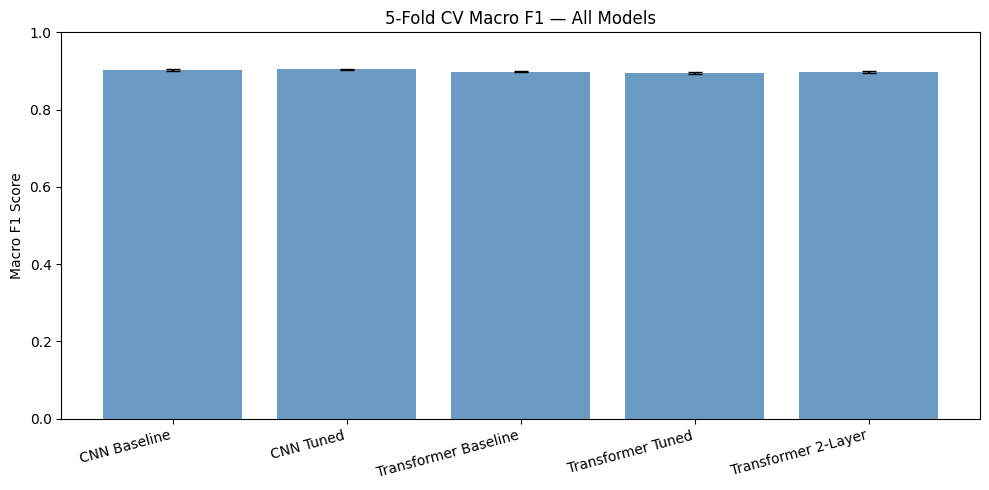

In [48]:
# Summary table + bar chart
model_names = ['CNN Baseline', 'CNN Tuned', 'Transformer Baseline',
               'Transformer Tuned', 'Transformer 2-Layer']
cv_results  = [cv_cnn_base, cv_cnn_tuned, cv_trans_base, cv_trans_tuned, cv_trans_2layer]

summary = pd.DataFrame({
    'Model': model_names,
    'Mean Macro F1': [np.mean(r) for r in cv_results],
    'Std':           [np.std(r)  for r in cv_results]
})
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(model_names, [np.mean(r) for r in cv_results],
       yerr=[np.std(r) for r in cv_results],
       capsize=5, color='steelblue', alpha=0.8)
ax.set_ylabel('Macro F1 Score')
ax.set_title('5-Fold CV Macro F1 — All Models')
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Statistical Comparison

We use the **Wilcoxon signed-rank test** (non-parametric, paired) because:
- Fold scores are paired — the same splits were used for all models.
- With only 5 folds we cannot assume normality.

Significance level: α = 0.05.

In [52]:
from itertools import combinations

print(f'{"Model A":<25} {"Model B":<25} {"p-value":>10} {"Significant?":>14}')
print('-' * 78)

for (i, a), (j, b) in combinations(enumerate(model_names), 2):
    _, p = stats.wilcoxon(cv_results[i], cv_results[j])
    print(f'{a:<25} {b:<25} {p:>10.4f} {"Yes *" if p < 0.05 else "No":>14}')

Model A                   Model B                      p-value   Significant?
------------------------------------------------------------------------------
CNN Baseline              CNN Tuned                     0.1250             No
CNN Baseline              Transformer Baseline          0.0625             No
CNN Baseline              Transformer Tuned             0.0625             No
CNN Baseline              Transformer 2-Layer           0.0625             No
CNN Tuned                 Transformer Baseline          0.0625             No
CNN Tuned                 Transformer Tuned             0.0625             No
CNN Tuned                 Transformer 2-Layer           0.0625             No
Transformer Baseline      Transformer Tuned             0.1250             No
Transformer Baseline      Transformer 2-Layer           0.4375             No
Transformer Tuned         Transformer 2-Layer           0.0625             No


### Interpretation of CV + Statistical Results

Ranking by mean Macro F1, best to worst:

1. CNN Tuned (num_filters=256): 0.9041 ± 0.0014
2. CNN Baseline (num_filters=128): 0.9014 ± 0.0027
3. Transformer Baseline (ff_dim=256): 0.8979 ± 0.0008
4. Transformer 2-Layer: 0.8976 ± 0.0022
5. Transformer Tuned (ff_dim=512): 0.8948 ± 0.0035

No pair came back as significant at p < 0.05. The smallest p-value any pair could get with 5 folds is 0.0625, which happens when one model wins on every single fold. So "not significant" here doesn't mean the models are equivalent. It just means we'd need more folds to prove the differences statistically. A lot of pairs hit that 0.0625 floor, which still tells us the model ordering is consistent.

Based on the results, we notice that the CNN beat the Transformer in every comparison. Every CNN-vs-Transformer pair had p = 0.0625, meaning the CNN won on all 5 folds in every case. The actual F1 gap is small, but it never reversed. This is a bit surprising since Transformers usually dominate NLP. However, we think it makes sense here because the sentiment in IMDB reviews mostly comes from short phrases like "not very good" or "absolutely loved," and CNNs are built for catching local patterns like that. The Transformer's strength, on the other hand, is mixing information across long distances, which doesn't help as much when the useful signal is already local. With only 40K training reviews per fold, the Transformer also doesn't have enough data to make use of its extra expressiveness.

Tuning helped the CNN but hurt the Transformer. Changing num_filters from 128 to 256 raised the CNN's F1 by about 0.003 while changing ff_dim from 256 to 512 actually lowered the Transformer's F1 by about 0.003. This is interesting because in Part 6, when we only looked at fold 0, the tuned Transformer looked slightly better than the baseline. Once we ran all 5 folds, we got a result that was opposite of what we expected, which shows the importance of cross-validation. 

The second attention layer didn't really help. Adding num_layers=2 raised the tuned Transformer's F1 from 0.8948 to 0.8976, which is a modest/small improvement and consistent across folds. However, the problem with this is that the 2-layer model is still slightly worse than the basic 1-layer Transformer Baseline (0.8979). So adding depth did not actually beat the simplest Transformer config. This showed to us that adding additional layers does not always improve the model, especially for a relatively simple task with limited training data.

The best model based on the results is the CNN Tuned model with num_filters=256. It had the highest mean F1 (0.9041) and the lowest fold-to-fold variation (std = 0.0014), so it's both the best and the most consistent.

One last note on the results is that every model overfit. Training loss dropped to almost zero while validation loss climbed steadily after a few epochs. Beacuse of this, this is why we decided to use the peak validation F1 per fold instead of the final-epoch F1, as the models did their best generalizing somewhere around epoch 3 to 5 before the overfitting began. 

---
## Part 9: Exceptional Work — ConceptNet Numberbatch vs. GloVe

ConceptNet Numberbatch encodes commonsense knowledge on top of distributional statistics (it's built by retrofitting word vectors against the ConceptNet knowledge graph, so words connected by relations like *IsA*, *PartOf*, *RelatedTo* end up closer in vector space than they would with raw co-occurrence stats).

We compare it against GloVe using the **best architecture from Part 8: the CNN with `num_filters=256`** (mean F1 = 0.9041). Holding architecture, folds, and all other hyperparameters constant isolates the embedding effect — any difference in F1 reflects only the choice of pretrained vectors.

**Embedding details:**
- GloVe: 100d, 400K words, trained on Wikipedia + Gigaword (~6B tokens)
- Numberbatch: 300d, ~516K English words, retrofitted from word2vec + GloVe + OpenSubtitles against ConceptNet

**Download:** `numberbatch-en-19.08.txt.gz` from https://conceptnet.io/

In [50]:
NUMBERBATCH_PATH = 'numberbatch-en.txt'
NUMBERBATCH_DIM  = 300

def load_numberbatch(path, word2idx, embed_dim=300):
    embedding_matrix = np.random.uniform(-0.1, 0.1, (len(word2idx), embed_dim))
    embedding_matrix[0] = 0
    found = 0
    with open(path, encoding='utf-8') as f:
        next(f)  # skip header
        for line in f:
            parts = line.split()
            word = parts[0]
            if word.startswith('/c/en/'):
                word = word[len('/c/en/'):]
            if word in word2idx:
                embedding_matrix[word2idx[word]] = np.array(parts[1:embed_dim+1], dtype=np.float32)
                found += 1
    print(f'Numberbatch coverage: {found}/{len(word2idx)} ({100*found/len(word2idx):.1f}%)')
    return torch.FloatTensor(embedding_matrix)

nb_weights = load_numberbatch(NUMBERBATCH_PATH, word2idx, NUMBERBATCH_DIM)

Numberbatch coverage: 18829/20000 (94.1%)


In [51]:
# Best architecture from Part 8 = CNN Tuned (num_filters=256, mean F1 = 0.9041)
# Re-run that exact architecture with Numberbatch embeddings instead of GloVe.
print('=== Best Architecture (CNN Tuned) + Numberbatch CV ===')
cv_nb = run_cross_validation(
    lambda: TextCNN(len(vocab), NUMBERBATCH_DIM, NUM_CLASSES,
                    num_filters=256, dropout=0.5,
                    pretrained_embeddings=nb_weights),
    folds, X, y
)

# Paired Wilcoxon: same architecture, same folds, only the embedding differs.
_, p = stats.wilcoxon(cv_cnn_tuned, cv_nb)
print(f'\nGloVe       mean F1: {np.mean(cv_cnn_tuned):.4f} +/- {np.std(cv_cnn_tuned):.4f}')
print(f'Numberbatch mean F1: {np.mean(cv_nb):.4f} +/- {np.std(cv_nb):.4f}')
print(f'GloVe vs Numberbatch p-value: {p:.4f}')

=== Best Architecture (CNN Tuned) + Numberbatch CV ===
  Fold 1/5...
  Epoch 1/15 | train_loss=0.3209 | val_loss=0.2447 | val_f1=0.8994
  Epoch 2/15 | train_loss=0.1634 | val_loss=0.2400 | val_f1=0.9040
  Epoch 3/15 | train_loss=0.0698 | val_loss=0.3105 | val_f1=0.8990
  Epoch 4/15 | train_loss=0.0321 | val_loss=0.4417 | val_f1=0.8907
  Epoch 5/15 | train_loss=0.0179 | val_loss=0.5163 | val_f1=0.8886
  Epoch 6/15 | train_loss=0.0160 | val_loss=0.5566 | val_f1=0.8941
  Epoch 7/15 | train_loss=0.0150 | val_loss=0.6236 | val_f1=0.8880
  Epoch 8/15 | train_loss=0.0162 | val_loss=0.7054 | val_f1=0.8871
  Epoch 9/15 | train_loss=0.0196 | val_loss=0.7499 | val_f1=0.8899
  Epoch 10/15 | train_loss=0.0149 | val_loss=0.7565 | val_f1=0.8915
  Epoch 11/15 | train_loss=0.0134 | val_loss=0.8733 | val_f1=0.8904
  Epoch 12/15 | train_loss=0.0157 | val_loss=0.8994 | val_f1=0.8863
  Epoch 13/15 | train_loss=0.0135 | val_loss=0.9967 | val_f1=0.8837
  Epoch 14/15 | train_loss=0.0111 | val_loss=1.0311 | va

**Jadon — write your interpretation here:**

- Which embedding performed better on this task, and by how much?
- Why might Numberbatch help or hurt for this specific dataset?
- What does this tell us about the value of commonsense knowledge for this classification task?

---
## Part 10: Summary and Conclusions

**TODO Jadon:** Fill in after all experiments are complete.

- Best model overall:
- Best hyperparameter settings:
- Did the second attention layer help? Why or why not?
- GloVe vs. Numberbatch conclusion:
- What surprised the team?
- Limitations and future work: